# Rune Goblin Vision Dataset Exploration

This notebook inspects the Rune Goblin visual dataset and the JSONL files used for vision fine-tuning.

It covers:
- dataset metadata from `README.md`, `schema.json`, and `validation_report.json`
- source records in `rune_goblin_visual_5000_full.jsonl`
- train/validation message JSONL files
- prepared absolute-path files for ms-swift and LLaMA-Factory
- assistant JSON validity, value ranges, category balance, rune frequencies, and image-path checks

Run this from the repo root with a Jupyter kernel using the project environment.

In [1]:
from __future__ import annotations

import json
import random
import statistics
import subprocess
import sys
from collections import Counter, defaultdict
from itertools import islice
from pathlib import Path

try:
    import pandas as pd
except ImportError:  # pandas is optional for this repo
    pd = None

try:
    from IPython.display import Image, Markdown, display
except ImportError:
    Image = Markdown = display = None

def find_repo_root(start: Path) -> Path:
    for path in [start, *start.parents]:
        if (path / "pyproject.toml").exists() and (path / "data").exists():
            return path
    raise FileNotFoundError("Could not find repo root. Start Jupyter from this repository.")


REPO_ROOT = find_repo_root(Path.cwd().resolve())
DATASET_ROOT = REPO_ROOT / "data/rune_goblin_visual_dataset_5000/rune_goblin_visual_dataset"
PREPARED_ROOT = REPO_ROOT / "data/vision_prepared"

FULL_JSONL = DATASET_ROOT / "rune_goblin_visual_5000_full.jsonl"
TRAIN_MESSAGES = DATASET_ROOT / "train_messages.jsonl"
VAL_MESSAGES = DATASET_ROOT / "validation_messages.jsonl"
TRAIN_HF_MESSAGES = DATASET_ROOT / "train_hf_vision_messages.jsonl"
VAL_HF_MESSAGES = DATASET_ROOT / "validation_hf_vision_messages.jsonl"
TRAIN_LLAVA = DATASET_ROOT / "train_llava_style.jsonl"
VAL_LLAVA = DATASET_ROOT / "validation_llava_style.jsonl"

SWIFT_TRAIN = PREPARED_ROOT / "vision_swift_train.jsonl"
SWIFT_VAL = PREPARED_ROOT / "vision_swift_val.jsonl"
SHAREGPT_TRAIN = PREPARED_ROOT / "vision_sharegpt_train.jsonl"
SHAREGPT_VAL = PREPARED_ROOT / "vision_sharegpt_val.jsonl"

random.seed(42690)

print(f"repo: {REPO_ROOT}")
print(f"dataset root exists: {DATASET_ROOT.exists()} -> {DATASET_ROOT}")
print(f"prepared root exists: {PREPARED_ROOT.exists()} -> {PREPARED_ROOT}")

repo: /home/ashu/github/goblin
dataset root exists: True -> /home/ashu/github/goblin/data/rune_goblin_visual_dataset_5000/rune_goblin_visual_dataset
prepared root exists: True -> /home/ashu/github/goblin/data/vision_prepared


In [2]:
def read_json(path: Path):
    with path.open() as f:
        return json.load(f)


def read_jsonl(path: Path, limit: int | None = None) -> list[dict]:
    with path.open() as f:
        lines = islice(f, limit) if limit is not None else f
        return [json.loads(line) for line in lines if line.strip()]


def count_jsonl(path: Path) -> int:
    with path.open() as f:
        return sum(1 for line in f if line.strip())


def ensure_prepared_datasets() -> None:
    required = [SWIFT_TRAIN, SWIFT_VAL, SHAREGPT_TRAIN, SHAREGPT_VAL]
    missing = [path for path in required if not path.exists()]
    if not missing:
        return

    script = REPO_ROOT / "scripts/prepare_vision_dataset.py"
    if not script.exists():
        missing_list = "\n".join(str(path) for path in missing)
        raise FileNotFoundError(
            "Prepared finetuning JSONL files are missing and the prepare script was not found.\n"
            f"Missing files:\n{missing_list}"
        )

    print("Prepared finetuning files are missing; generating data/vision_prepared/ ...")
    subprocess.run(
        [
            sys.executable,
            str(script),
            "--src",
            str(DATASET_ROOT),
            "--out",
            str(PREPARED_ROOT),
            "--skip-missing-images",
        ],
        cwd=REPO_ROOT,
        check=True,
    )


def assistant_content(messages: list[dict]) -> str:
    return next(m["content"] for m in messages if m["role"] == "assistant")


def user_content(messages: list[dict]) -> str:
    return next(m["content"] for m in messages if m["role"] == "user")


def parse_assistant_json(record: dict) -> dict:
    return json.loads(assistant_content(record["messages"]))


def show_table(rows: list[dict], max_rows: int = 20):
    if pd is not None and display is not None:
        display(pd.DataFrame(rows).head(max_rows))
    else:
        for row in rows[:max_rows]:
            print(row)


def pct(part: int | float, total: int | float) -> float:
    return round((part / total) * 100, 2) if total else 0.0

## Dataset Metadata

Read the bundled schema and validation report before looking at examples. These files define the intended task, output shape, counts, and image assumptions.

In [3]:
schema = read_json(DATASET_ROOT / "schema.json")
validation_report = read_json(DATASET_ROOT / "validation_report.json")

metadata_rows = [
    {"field": "dataset_name", "value": schema.get("dataset_name")},
    {"field": "version", "value": schema.get("version")},
    {"field": "task", "value": schema.get("task")},
    {"field": "image_size", "value": schema.get("image_size")},
    {"field": "total_records", "value": validation_report.get("total_records")},
    {"field": "train_records", "value": validation_report.get("train_records")},
    {"field": "validation_records", "value": validation_report.get("validation_records")},
    {"field": "assistant_json_valid", "value": validation_report.get("assistant_json_valid")},
    {"field": "assistant_json_invalid", "value": validation_report.get("assistant_json_invalid")},
]
show_table(metadata_rows)

,field,value
0,dataset_name,rune-goblin-visual-spell-5000
1,version,1.0.0
2,task,canvas image + game state -> visual_reading + ...
3,image_size,"[256, 256]"
4,total_records,5000
5,train_records,4500
6,validation_records,500
7,assistant_json_valid,5000
8,assistant_json_invalid,0


In [4]:
print("Rune vocabulary:")
show_table([{"rune": rune, "meaning": meaning} for rune, meaning in schema["runes"].items()])

print("\nCombo rules:")
show_table([
    {"combo": combo, "spell_type": info["spell_type"], "meaning": info["meaning"]}
    for combo, info in schema["combo_rules"].items()
])

Rune vocabulary:


,rune,meaning
0,spiral,"time, confusion, loops"
1,jagged_line,"damage, lightning, cutting"
2,closed_circle,"shield, trap, containment"
3,three_dots,"swarm, insects, multiplication"
4,wave,"water, emotion, softness"
5,eye,"reveal, inspect, prophecy"
6,bone,"fear, death, skeleton"
7,leaf,"healing, growth, poison"
8,flame,"burn, passion, danger"
9,key,"unlock, escape, secrets"



Combo rules:


,combo,spell_type,meaning
0,eye+spiral,prophecy_loop,prophecy / see future move
1,closed_circle+flame,burning_shield,burning shield
2,bone+three_dots,skeleton_swarm,skeleton swarm
3,jagged_line+mirror,damage_reflection,reflect damage
4,key+wave,emotional_unlock,unlock emotional door
5,thread+tooth,bind_and_bite,bind and bite
6,bell+coin,merchant_spirit,summon a merchant spirit
7,bone+leaf,decay_healing,healing with decay risk
8,eye+mirror,weakness_reveal,reveal enemy weakness


## File Inventory

The source dataset uses relative image paths. The prepared finetuning files use absolute paths, which most vision fine-tuning tools expect.

In [5]:
jsonl_files = [
    FULL_JSONL,
    TRAIN_MESSAGES,
    VAL_MESSAGES,
    TRAIN_HF_MESSAGES,
    VAL_HF_MESSAGES,
    TRAIN_LLAVA,
    VAL_LLAVA,
    SWIFT_TRAIN,
    SWIFT_VAL,
    SHAREGPT_TRAIN,
    SHAREGPT_VAL,
]

file_rows = []
for path in jsonl_files:
    file_rows.append({
        "file": str(path.relative_to(REPO_ROOT)),
        "exists": path.exists(),
        "records": count_jsonl(path) if path.exists() else None,
        "size_mb": round(path.stat().st_size / 1_000_000, 2) if path.exists() else None,
    })
show_table(file_rows, max_rows=30)

,file,exists,records,size_mb
0,data/rune_goblin_visual_dataset_5000/rune_gobl...,True,5000,9.52
1,data/rune_goblin_visual_dataset_5000/rune_gobl...,True,4500,6.76
2,data/rune_goblin_visual_dataset_5000/rune_gobl...,True,500,0.75
3,data/rune_goblin_visual_dataset_5000/rune_gobl...,True,4500,7.09
4,data/rune_goblin_visual_dataset_5000/rune_gobl...,True,500,0.79
5,data/rune_goblin_visual_dataset_5000/rune_gobl...,True,4500,6.64
6,data/rune_goblin_visual_dataset_5000/rune_gobl...,True,500,0.74
7,data/vision_prepared/vision_swift_train.jsonl,True,4499,7.08
8,data/vision_prepared/vision_swift_val.jsonl,True,500,0.79
9,data/vision_prepared/vision_sharegpt_train.jsonl,True,4499,6.97


In [6]:
ensure_prepared_datasets()

full_records = read_jsonl(FULL_JSONL)
train_records = read_jsonl(TRAIN_MESSAGES)
val_records = read_jsonl(VAL_MESSAGES)
swift_train_sample = read_jsonl(SWIFT_TRAIN, limit=3)
sharegpt_train_sample = read_jsonl(SHAREGPT_TRAIN, limit=3)

print(f"loaded full records: {len(full_records)}")
print(f"loaded train/val message records: {len(train_records)} / {len(val_records)}")
print("first full-record keys:", list(full_records[0].keys()))
print("first prepared ms-swift keys:", list(swift_train_sample[0].keys()))
print("first prepared ShareGPT keys:", list(sharegpt_train_sample[0].keys()))

loaded full records: 5000
loaded train/val message records: 4500 / 500
first full-record keys: ['id', 'category', 'image', 'image_sha256', 'width', 'height', 'runes_ground_truth', 'game_state', 'messages']
first prepared ms-swift keys: ['messages', 'images']
first prepared ShareGPT keys: ['conversations', 'system', 'images']


## Split And Category Balance

In [7]:
full_by_image = {rec["image"]: rec for rec in full_records}
train_images = {rec["image"] for rec in train_records}
val_images = {rec["image"] for rec in val_records}

print("train/val overlap:", len(train_images & val_images))
print("train + val equals full:", len(train_images | val_images) == len(full_records))

def category_counts_for(images: set[str]) -> Counter:
    return Counter(full_by_image[image]["category"] for image in images)

train_category_counts = category_counts_for(train_images)
val_category_counts = category_counts_for(val_images)
all_category_counts = Counter(rec["category"] for rec in full_records)

rows = []
for category in sorted(all_category_counts):
    rows.append({
        "category": category,
        "all": all_category_counts[category],
        "all_pct": pct(all_category_counts[category], len(full_records)),
        "train": train_category_counts[category],
        "train_pct": pct(train_category_counts[category], len(train_records)),
        "val": val_category_counts[category],
        "val_pct": pct(val_category_counts[category], len(val_records)),
    })
show_table(rows)

train/val overlap: 0
train + val equals full: True


,category,all,all_pct,train,train_pct,val,val_pct
0,basic_clean,1000,20.0,905,20.11,95,19.0
1,combo_rules,1100,22.0,985,21.89,115,23.0
2,cursed_broken_mark,700,14.0,629,13.98,71,14.2
3,enemy_specific,700,14.0,637,14.16,63,12.6
4,invalid_ambiguous,300,6.0,269,5.98,31,6.2
5,messy_handdrawn,1200,24.0,1075,23.89,125,25.0


## Visual Preview

The dataset includes 256x256 JPEG canvases plus a contact sheet preview.

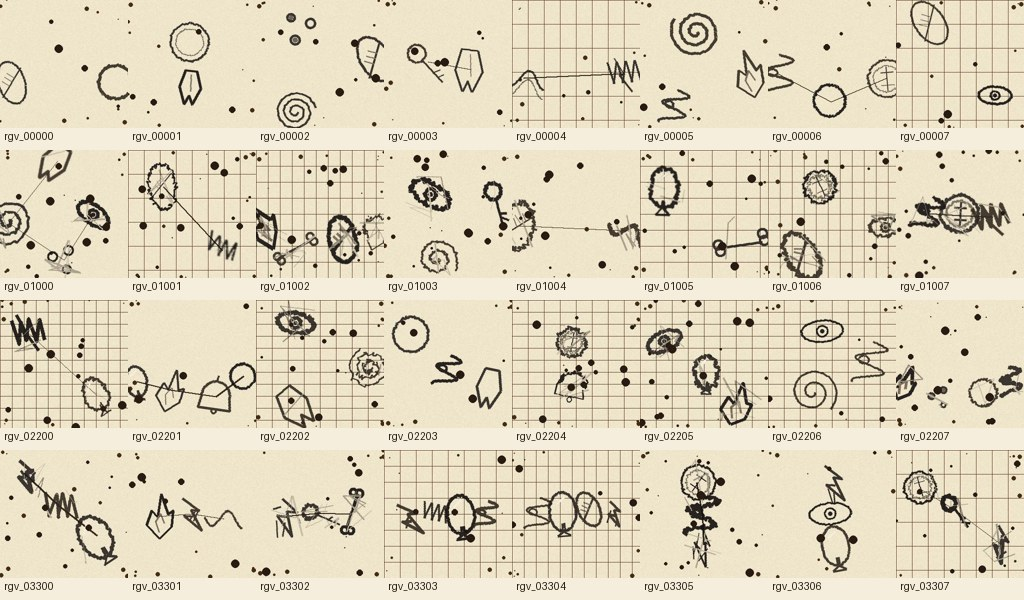

In [8]:
contact_sheet = DATASET_ROOT / "previews/contact_sheet_32.jpg"
if Image is not None and contact_sheet.exists():
    display(Image(filename=str(contact_sheet)))
else:
    print(contact_sheet)

id: rgv_03780
category: cursed_broken_mark
image: /home/ashu/github/goblin/data/rune_goblin_visual_dataset_5000/rune_goblin_visual_dataset/images/rgv_03780.jpg
runes_ground_truth: ['broken_mark', 'closed_circle', 'key']
game_state: {'player_hp': 7, 'enemy': 'Queue Goblin', 'enemy_hp': 3, 'enemy_max_hp': 7, 'weakness': 'bell, coin', 'resistance': 'flame', 'room': 'Refund Crypt', 'room_mood': 'echoing', 'inventory': ['leaf bandage', 'rubber bone']}

user prompt:
 <image>
STATE: player_hp=7 enemy=Queue Goblin enemy_hp=3 weakness=bell, coin resistance=flame room=Refund Crypt room_mood=echoing inventory=[leaf bandage, rubber bone]
Look at the drawn RuneLang spell on the canvas and return visual_reading plus spell JSON only.

assistant target JSON:
{
  "visual_reading": {
    "detected_runes": [
      "broken_mark",
      "closed_circle",
      "key"
    ],
    "ambiguous_runes": [],
    "drawing_style": "clear black ink",
    "layout": "loose circular cluster",
    "confidence": 0.7,
    "n

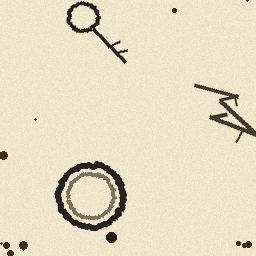

In [9]:
def show_record(record: dict):
    image_path = DATASET_ROOT / record["image"]
    target = parse_assistant_json(record)
    print("id:", record.get("id"))
    print("category:", record.get("category"))
    print("image:", image_path)
    print("runes_ground_truth:", record.get("runes_ground_truth"))
    print("game_state:", record.get("game_state"))
    print("\nuser prompt:\n", user_content(record["messages"]))
    print("\nassistant target JSON:")
    print(json.dumps(target, indent=2))
    if Image is not None and image_path.exists():
        display(Image(filename=str(image_path), width=256, height=256))


sample_record = random.choice(full_records)
show_record(sample_record)

## Assistant JSON Quality Checks

These checks verify that every assistant response parses as JSON and stays inside the expected gameplay ranges.

In [10]:
required_top_keys = {"visual_reading", "spell"}
required_visual_keys = {"detected_runes", "ambiguous_runes", "drawing_style", "layout", "confidence", "notes"}
required_spell_keys = {
    "spell_name",
    "spell_type",
    "flavor",
    "effect",
    "side_effect",
    "enemy_hp_delta",
    "player_hp_delta",
    "status_effects",
    "chaos",
}

errors = []
targets = []
for rec in full_records:
    try:
        target = parse_assistant_json(rec)
        targets.append((rec, target))
    except Exception as exc:
        errors.append((rec.get("id"), "json_parse", str(exc)))
        continue

    if set(target) != required_top_keys:
        errors.append((rec.get("id"), "top_keys", sorted(target)))
    visual = target.get("visual_reading", {})
    spell = target.get("spell", {})
    missing_visual = required_visual_keys - set(visual)
    missing_spell = required_spell_keys - set(spell)
    if missing_visual:
        errors.append((rec.get("id"), "missing_visual", sorted(missing_visual)))
    if missing_spell:
        errors.append((rec.get("id"), "missing_spell", sorted(missing_spell)))

    confidence = visual.get("confidence")
    chaos = spell.get("chaos")
    enemy_delta = spell.get("enemy_hp_delta")
    player_delta = spell.get("player_hp_delta")
    if not isinstance(confidence, (int, float)) or not 0 <= confidence <= 1:
        errors.append((rec.get("id"), "confidence_range", confidence))
    if not isinstance(chaos, int) or not 1 <= chaos <= 10:
        errors.append((rec.get("id"), "chaos_range", chaos))
    if not isinstance(enemy_delta, int) or not -4 <= enemy_delta <= 0:
        errors.append((rec.get("id"), "enemy_hp_delta_range", enemy_delta))
    if not isinstance(player_delta, int) or not -3 <= player_delta <= 2:
        errors.append((rec.get("id"), "player_hp_delta_range", player_delta))

print(f"valid parsed targets: {len(targets)} / {len(full_records)}")
print(f"errors: {len(errors)}")
show_table([{"id": e[0], "check": e[1], "value": e[2]} for e in errors[:20]])

valid parsed targets: 5000 / 5000
errors: 0


""


In [11]:
by_category = defaultdict(lambda: {"confidence": [], "chaos": [], "enemy_hp_delta": [], "player_hp_delta": []})
for rec, target in targets:
    category = rec["category"]
    by_category[category]["confidence"].append(target["visual_reading"]["confidence"])
    by_category[category]["chaos"].append(target["spell"]["chaos"])
    by_category[category]["enemy_hp_delta"].append(target["spell"]["enemy_hp_delta"])
    by_category[category]["player_hp_delta"].append(target["spell"]["player_hp_delta"])

summary_rows = []
for category, values in sorted(by_category.items()):
    summary_rows.append({
        "category": category,
        "n": len(values["confidence"]),
        "avg_confidence": round(statistics.mean(values["confidence"]), 3),
        "min_confidence": min(values["confidence"]),
        "max_confidence": max(values["confidence"]),
        "avg_chaos": round(statistics.mean(values["chaos"]), 3),
        "avg_enemy_hp_delta": round(statistics.mean(values["enemy_hp_delta"]), 3),
        "avg_player_hp_delta": round(statistics.mean(values["player_hp_delta"]), 3),
    })
show_table(summary_rows)

,category,n,avg_confidence,min_confidence,max_confidence,avg_chaos,avg_enemy_hp_delta,avg_player_hp_delta
0,basic_clean,1000,0.918,0.86,0.98,4.014,-0.803,0.107
1,combo_rules,1100,0.851,0.74,0.96,5.292,-2.322,0.041
2,cursed_broken_mark,700,0.806,0.68,0.93,6.394,-1.807,-0.746
3,enemy_specific,700,0.822,0.70,0.95,4.739,-1.854,-0.010
4,invalid_ambiguous,300,0.418,0.18,0.65,8.367,-0.157,0.017
5,messy_handdrawn,1200,0.768,0.66,0.88,5.452,-1.516,-0.028


## Rune, Spell, And Status Frequencies

In [12]:
gt_runes = Counter()
detected_runes = Counter()
ambiguous_runes = Counter()
spell_types = Counter()
status_effects = Counter()

for rec, target in targets:
    gt_runes.update(rec.get("runes_ground_truth", []))
    detected_runes.update(target["visual_reading"].get("detected_runes", []))
    ambiguous_runes.update(target["visual_reading"].get("ambiguous_runes", []))
    spell_types[target["spell"].get("spell_type")] += 1
    status_effects.update(target["spell"].get("status_effects", []))

print("Ground-truth rune counts:")
show_table([{"rune": k, "count": v} for k, v in gt_runes.most_common()], max_rows=30)

print("\nDetected rune counts in assistant JSON:")
show_table([{"rune": k, "count": v} for k, v in detected_runes.most_common()], max_rows=30)

print("\nTop spell types:")
show_table([{"spell_type": k, "count": v} for k, v in spell_types.most_common(30)], max_rows=30)

print("\nTop status effects:")
show_table([{"status_effect": k, "count": v} for k, v in status_effects.most_common(30)], max_rows=30)

Ground-truth rune counts:


,rune,count
0,mirror,984
1,bone,966
2,flame,952
3,broken_mark,951
4,eye,947
5,jagged_line,930
6,bell,911
7,coin,908
8,spiral,869
9,leaf,856



Detected rune counts in assistant JSON:


,rune,count
0,mirror,973
1,bone,955
2,broken_mark,951
3,eye,942
4,flame,941
5,jagged_line,924
6,coin,900
7,bell,899
8,spiral,853
9,leaf,844



Top spell types:


,spell_type,count
0,invalid_or_ambiguous,254
1,damage_reflection,211
2,skeleton_swarm,189
3,prophecy_loop,181
4,burning_shield,179
5,bind_and_bite,173
6,merchant_spirit,172
7,decay_healing,165
8,emotional_unlock,153
9,weakness_reveal,123



Top status effects:


,status_effect,count
0,weakness_triggered,2009
1,player_reflecting,954
2,spell_cursed,950
3,enemy_frightened,935
4,resistance_reduced_effect,922
5,enemy_burning,919
6,enemy_revealed,917
7,enemy_shocked,901
8,merchant_marked,879
9,enemy_startled,870


## JSONL Format Inspection

Compare the source message format against the two prepared formats used for fine-tuning.

In [13]:
source_example = train_records[0]
swift_example = swift_train_sample[0]
sharegpt_example = sharegpt_train_sample[0]

print("Source train_messages.jsonl example:")
print(json.dumps(source_example, indent=2)[:2500])

print("\nPrepared ms-swift example:")
print(json.dumps(swift_example, indent=2)[:2500])

print("\nPrepared ShareGPT example:")
print(json.dumps(sharegpt_example, indent=2)[:2500])

Source train_messages.jsonl example:
{
  "id": "rgv_02464",
  "image": "images/rgv_02464.jpg",
  "messages": [
    {
      "role": "system",
      "content": "You are Rune Goblin, a tiny vision spell engine. Read hand-drawn RuneLang glyphs from the image, infer the drawn runes, apply RuneLang combo rules and the game state, then output valid JSON only. The JSON must contain visual_reading and spell. Spells should be weird, funny, balanced, and game-safe."
    },
    {
      "role": "user",
      "content": "<image>\nSTATE: player_hp=4 enemy=Wet Librarian enemy_hp=5 weakness=bell, leaf resistance=flame room=The Wet Library room_mood=too quiet inventory=[mirror shard, sad onion]\nLook at the drawn RuneLang spell on the canvas and return visual_reading plus spell JSON only."
    },
    {
      "role": "assistant",
      "content": "{\"visual_reading\":{\"detected_runes\":[\"leaf\",\"bone\"],\"ambiguous_runes\":[],\"drawing_style\":\"uneven mouse-drawn strokes\",\"layout\":\"loose circular

In [14]:
def validate_swift_record(record: dict) -> list[str]:
    problems = []
    if set(record) != {"messages", "images"}:
        problems.append(f"unexpected keys: {sorted(record)}")
    if not isinstance(record.get("images"), list) or len(record["images"]) != 1:
        problems.append("images must be a one-item list")
    else:
        image_path = Path(record["images"][0])
        if not image_path.is_absolute():
            problems.append("image path is not absolute")
        if not image_path.exists():
            problems.append(f"image path missing: {image_path}")
    roles = [m.get("role") for m in record.get("messages", [])]
    if roles != ["system", "user", "assistant"]:
        problems.append(f"unexpected roles: {roles}")
    if "<image>" not in user_content(record.get("messages", [])):
        problems.append("user message missing <image> token")
    try:
        parse_assistant_json(record)
    except Exception as exc:
        problems.append(f"assistant JSON invalid: {exc}")
    return problems


def validate_sharegpt_record(record: dict) -> list[str]:
    problems = []
    if set(record) != {"conversations", "images", "system"}:
        problems.append(f"unexpected keys: {sorted(record)}")
    if not isinstance(record.get("images"), list) or len(record["images"]) != 1:
        problems.append("images must be a one-item list")
    else:
        image_path = Path(record["images"][0])
        if not image_path.is_absolute():
            problems.append("image path is not absolute")
        if not image_path.exists():
            problems.append(f"image path missing: {image_path}")
    turns = record.get("conversations", [])
    roles = [turn.get("from") for turn in turns]
    if roles != ["human", "gpt"]:
        problems.append(f"unexpected conversation roles: {roles}")
    if turns and "<image>" not in turns[0].get("value", ""):
        problems.append("human turn missing <image> token")
    try:
        gpt_value = turns[1].get("value", "") if len(turns) > 1 else ""
        json.loads(gpt_value)
    except Exception as exc:
        problems.append(f"gpt JSON invalid: {exc}")
    return problems


def validate_jsonl(path: Path, validator, limit: int | None = None) -> list[dict]:
    problems = []
    for i, record in enumerate(read_jsonl(path, limit=limit), start=1):
        record_problems = validator(record)
        for problem in record_problems:
            problems.append({"file": str(path.relative_to(REPO_ROOT)), "line": i, "problem": problem})
    return problems


format_problems = []
format_problems.extend(validate_jsonl(SWIFT_TRAIN, validate_swift_record))
format_problems.extend(validate_jsonl(SWIFT_VAL, validate_swift_record))
format_problems.extend(validate_jsonl(SHAREGPT_TRAIN, validate_sharegpt_record))
format_problems.extend(validate_jsonl(SHAREGPT_VAL, validate_sharegpt_record))

print(f"prepared-format problems: {len(format_problems)}")
show_table(format_problems[:30], max_rows=30)

prepared-format problems: 0


""


## Token And Length Proxies

This is not tokenizer-accurate, but it helps catch unusually long prompts or targets before training.

In [15]:
length_rows = []
for rec in train_records + val_records:
    user_text = user_content(rec["messages"])
    assistant_text = assistant_content(rec["messages"])
    length_rows.append({
        "image": rec["image"],
        "user_chars": len(user_text),
        "assistant_chars": len(assistant_text),
        "assistant_words": len(assistant_text.split()),
    })

for column in ["user_chars", "assistant_chars", "assistant_words"]:
    values = [row[column] for row in length_rows]
    print(column, {
        "min": min(values),
        "p50": sorted(values)[len(values) // 2],
        "p95": sorted(values)[int(len(values) * 0.95)],
        "max": max(values),
        "mean": round(statistics.mean(values), 2),
    })

print("\nLongest assistant targets:")
show_table(sorted(length_rows, key=lambda row: row["assistant_chars"], reverse=True)[:10])

user_chars {'min': 236, 'p50': 278, 'p95': 303, 'max': 330, 'mean': 277.7}
assistant_chars {'min': 533, 'p50': 683, 'p95': 810, 'max': 970, 'mean': 686.55}
assistant_words {'min': 25, 'p50': 41, 'p95': 55, 'max': 68, 'mean': 41.96}

Longest assistant targets:


,image,user_chars,assistant_chars,assistant_words
0,images/rgv_01167.jpg,317,970,67
1,images/rgv_04546.jpg,308,940,68
2,images/rgv_03790.jpg,288,930,64
3,images/rgv_01727.jpg,253,926,64
4,images/rgv_03549.jpg,311,916,61
5,images/rgv_04894.jpg,270,912,58
6,images/rgv_03523.jpg,257,910,61
7,images/rgv_04066.jpg,295,908,65
8,images/rgv_02329.jpg,283,905,68
9,images/rgv_01024.jpg,271,904,61


## Optional Debug Subsets

Set `WRITE_DEBUG_SUBSETS = True` to write tiny local JSONL slices for smoke-testing a fine-tuning command before using all 4,500 training records.

In [16]:
WRITE_DEBUG_SUBSETS = False

if WRITE_DEBUG_SUBSETS:
    debug_dir = PREPARED_ROOT / "debug_subsets"
    debug_dir.mkdir(parents=True, exist_ok=True)

    for src, dst_name, n in [
        (SWIFT_TRAIN, "vision_swift_train_32.jsonl", 32),
        (SWIFT_VAL, "vision_swift_val_8.jsonl", 8),
        (SHAREGPT_TRAIN, "vision_sharegpt_train_32.jsonl", 32),
        (SHAREGPT_VAL, "vision_sharegpt_val_8.jsonl", 8),
    ]:
        dst = debug_dir / dst_name
        records = read_jsonl(src, limit=n)
        with dst.open("w") as f:
            for rec in records:
                f.write(json.dumps(rec, ensure_ascii=False) + "\n")
        print(f"wrote {len(records)} records -> {dst}")
else:
    print("Debug subset writing is disabled.")

Debug subset writing is disabled.


## Fine-Tuning Files To Use

Recommended prepared files:

- ms-swift train: `data/vision_prepared/vision_swift_train.jsonl`
- ms-swift val: `data/vision_prepared/vision_swift_val.jsonl`
- LLaMA-Factory train: `data/vision_prepared/vision_sharegpt_train.jsonl`
- LLaMA-Factory val: `data/vision_prepared/vision_sharegpt_val.jsonl`

If these files are missing or stale, regenerate them from relative-path source files:

```bash
uv run python scripts/prepare_vision_dataset.py
```

The project finetuning guide is in `docs/FINETUNE_VISION.md`.